Step: 0, dt=1.12606e-06
Step: 500, dt=1.12606e-06


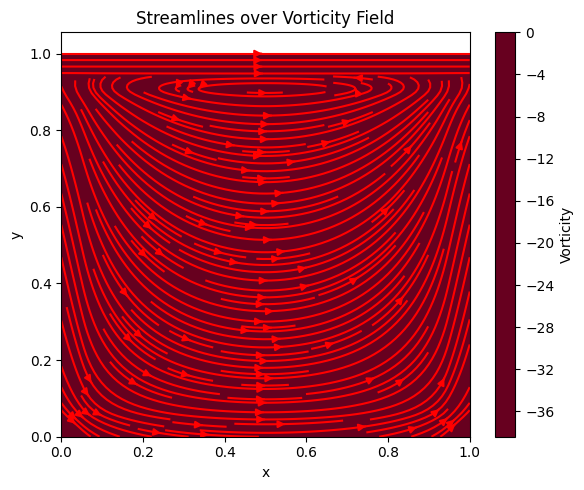

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# -----------------------------
# PARAMETERS
# -----------------------------
Nx, Ny = 20, 20
Lx, Ly = 1.0, 1.0
Re = 1000.0
U_lid = 1.0
nu = 1.0 / Re

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

nt = 1000

# -----------------------------
# GRID
# -----------------------------
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

# -----------------------------
# FIELDS
# -----------------------------
psi = np.zeros((Nx, Ny))
omega = np.zeros((Nx, Ny))
u = np.zeros((Nx, Ny))
v = np.zeros((Nx, Ny))

# -----------------------------
# POISSON SOLVER (fast GS-like)
# -----------------------------
def solve_psi(psi, omega, tol=1e-5, max_iter=5000):
    for _ in range(max_iter):
        psi_old = psi.copy()

        psi[1:-1,1:-1] = 0.25 * (
            psi[2:,1:-1] + psi[:-2,1:-1] +
            psi[1:-1,2:] + psi[1:-1,:-2] +
            dx**2 * (-omega[1:-1,1:-1])
        )

        # Dirichlet BC
        psi[:,0] = 0
        psi[:,-1] = 0
        psi[0,:] = 0
        psi[-1,:] = 0

        if np.max(np.abs(psi - psi_old)) < tol:
            break

    return psi

# -----------------------------
# TIME LOOP ( Euler Explicit Method)
# -----------------------------
for n in range(nt):

    # -------------------------
    # VELOCITY
    # -------------------------
    u[1:-1,1:-1] = (psi[1:-1,2:] - psi[1:-1,:-2]) / (2*dy)
    v[1:-1,1:-1] = -(psi[2:,1:-1] - psi[:-2,1:-1]) / (2*dx)

    # Lid BC
    u[:, -1] = U_lid
    v[:, -1] = 0

    # -------------------------
    # ADAPTIVE DT (CFL)
    # -------------------------
    umax = np.max(np.abs(u))
    vmax = np.max(np.abs(v))

    dt_adv = min(dx/(umax+1e-8), dy/(vmax+1e-8))
    dt_diff = Re * dx**2 * dy**2 / (2*(dx**2 + dy**2))

    dt = 0.4 * min(dt_adv, dt_diff)

    omega_old = omega.copy()

    # -------------------------
    # UPWIND (vectorized)
    # -------------------------
    dwdx_back = (omega[1:-1,1:-1] - omega[:-2,1:-1]) / dx
    dwdx_forw = (omega[2:,1:-1] - omega[1:-1,1:-1]) / dx
    dwdx = np.where(u[1:-1,1:-1] > 0, dwdx_back, dwdx_forw)

    dwdy_back = (omega[1:-1,1:-1] - omega[1:-1,:-2]) / dy
    dwdy_forw = (omega[1:-1,2:] - omega[1:-1,1:-1]) / dy
    dwdy = np.where(v[1:-1,1:-1] > 0, dwdy_back, dwdy_forw)

    adv = u[1:-1,1:-1]*dwdx + v[1:-1,1:-1]*dwdy

    # -------------------------
    # DIFFUSION
    # -------------------------
    lap = (
        (omega[2:,1:-1] - 2*omega[1:-1,1:-1] + omega[:-2,1:-1]) / dx**2 +
        (omega[1:-1,2:] - 2*omega[1:-1,1:-1] + omega[1:-1,:-2]) / dy**2
    )



    # -------------------------
    # UPDATE ω
    # -------------------------
    omega[1:-1,1:-1] = omega_old[1:-1,1:-1] + dt * (
        -adv + nu * lap
    )

    # -------------------------
    # VORTICITY BCs
    # -------------------------
    omega[:,0]  = -2 * psi[:,1] / dy**2
    omega[:,-1] = -2 * psi[:,-2] / dy**2 - 2*U_lid/dy   ## Global Conservation we enforce Psi at the Open boundary it is zero s
    omega[0,:]  = -2 * psi[1,:] / dx**2
    omega[-1,:] = -2 * psi[-2,:] / dx**2

    # -------------------------
    # STABILITY GUARDS
    # -------------------------
    omega = np.clip(omega, -1e5, 1e5)

    if np.isnan(omega).any():
        print(f"NaN detected at step {n}")
        break

    # -------------------------
    # SOLVE ψ
    # -------------------------
    psi = solve_psi(psi, omega)

    if n % 500 == 0:
        print(f"Step: {n}, dt={dt:.5e}")

# -----------------------------
# POST-PROCESSING
# -----------------------------
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(6,5))

# Plot vorticity field


norm = colors.Normalize(vmin=-1e4, vmax=0)
cf = plt.contourf(X, Y, omega.T, 50, cmap='RdBu_r', norm=norm)
plt.colorbar(cf, label="Vorticity")


# Overlay streamlines
plt.streamplot(X, Y, u.T, v.T, color='r', density=2.0, arrowsize=1)

plt.title("Streamlines over Vorticity Field")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

